In [2]:
import sys
print(sys.executable)

/home/katamdeepika/Desktop/genai/.venv/bin/python


In [3]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

print("tiktoken is working!")

tiktoken is working!


In [4]:
text = "I love chicken biriyani"
tokens = encoding.encode(text)
print(tokens)

[40, 3021, 16553, 15606, 16618, 5676]


In [5]:
print("Number of tokens:", len(tokens))

Number of tokens: 6


In [6]:
print("Text:", text)
print("Token IDs:", tokens)
print("Number of tokens:", len(tokens))

Text: I love chicken biriyani
Token IDs: [40, 3021, 16553, 15606, 16618, 5676]
Number of tokens: 6


In [7]:
for token in tokens:
    print(token, encoding.decode_single_token_bytes(token))

40 b'I'
3021 b' love'
16553 b' chicken'
15606 b' bir'
16618 b'iy'
5676 b'ani'


In [8]:
text = "I love chicken biriyani"
tokens = encoding.encode(text)
print("Original text:", text)
print("Token IDs:", tokens)
decoded_text = encoding.decode(tokens)
print("Decoded text:", decoded_text)

Original text: I love chicken biriyani
Token IDs: [40, 3021, 16553, 15606, 16618, 5676]
Decoded text: I love chicken biriyani


In [9]:
words = [
    "hello",
    "biriyani",
    "tokenization",
    "unbelievable",
    "internationalization"
]

for word in words:
    tokens = encoding.encode(word)
    print("\nWord:", word)
    print("Token IDs:", tokens)
    for token in tokens:
        print("   ", repr(encoding.decode([token])))


Word: hello
Token IDs: [15339]
    'hello'

Word: biriyani
Token IDs: [44955, 16618, 5676]
    'bir'
    'iy'
    'ani'

Word: tokenization
Token IDs: [5963, 2065]
    'token'
    'ization'

Word: unbelievable
Token IDs: [359, 32898, 24694]
    'un'
    'belie'
    'vable'

Word: internationalization
Token IDs: [98697, 2065]
    'international'
    'ization'


In [11]:
texts = [
    "I love chicken",
    "Ilovechicken",
    "I-love-chicken",
    "I love chicken!"
]

for text in texts:
    tokens = encoding.encode(text)
    print("\nText:", repr(text))
    print("Tokens:", tokens)
    print("Number of tokens:", len(tokens))


Text: 'I love chicken'
Tokens: [40, 3021, 16553]
Number of tokens: 3

Text: 'Ilovechicken'
Tokens: [40, 31153, 331, 9890]
Number of tokens: 4

Text: 'I-love-chicken'
Tokens: [40, 27578, 588, 11843, 9890]
Number of tokens: 5

Text: 'I love chicken!'
Tokens: [40, 3021, 16553, 0]
Number of tokens: 4


In [12]:
texts = [
    "I love chicken",
    "Ilovechicken",
    "I-love-chicken",
    "I love chicken!"
]
for text in texts:
    print("\nTEXT:", repr(text))
    tokens = encoding.encode(text)
    for token in tokens:
        print(token, repr(encoding.decode([token])))


TEXT: 'I love chicken'
40 'I'
3021 ' love'
16553 ' chicken'

TEXT: 'Ilovechicken'
40 'I'
31153 'love'
331 'ch'
9890 'icken'

TEXT: 'I-love-chicken'
40 'I'
27578 '-lo'
588 've'
11843 '-ch'
9890 'icken'

TEXT: 'I love chicken!'
40 'I'
3021 ' love'
16553 ' chicken'
0 '!'


In [13]:
from sentence_transformers import SentenceTransformer

/home/katamdeepika/Desktop/genai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 3747.06it/s]


In [15]:
print(model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


In [16]:
text = "I love chicken biriyani"

embedding = model.encode(text)

print("Text:", text)
print("Embedding dimensions:", len(embedding))
print(embedding)

Text: I love chicken biriyani
Embedding dimensions: 384
[-5.43347187e-02 -1.58979893e-02 -2.86504738e-02 -2.70110480e-02
 -6.12546951e-02 -5.13292737e-02  1.40894160e-01 -2.55783983e-02
  8.91736150e-02 -5.46937399e-02 -3.30604836e-02 -9.49881226e-02
 -2.44531408e-02  2.10602563e-02  3.66011746e-02  1.88708883e-02
  8.06609988e-02  6.26589078e-03  1.08931924e-03 -3.85859348e-02
 -1.20621033e-01  1.35150077e-02  5.32570854e-02  3.48880962e-02
 -7.08867013e-02 -5.55519424e-02  9.31387544e-02  6.04184009e-02
 -6.41366765e-02  1.90863488e-04  8.75062775e-03  5.12626730e-02
 -1.02230506e-02 -4.37856140e-03 -3.18392925e-02  4.05253768e-02
 -2.95782350e-02 -5.85084520e-02  1.18966423e-01  4.45031635e-02
  4.23345380e-02  7.14257258e-05  1.10524550e-01 -1.31418675e-01
  9.77424532e-03 -5.38319238e-02 -7.27015808e-02 -9.95528698e-03
  9.95604023e-02 -5.55903055e-02 -4.49492633e-02  8.45040847e-03
 -1.02038868e-02  3.89945926e-04  6.57321364e-02  5.55930138e-02
 -6.12245463e-02 -7.57495984e-02 -

In [17]:
for i, value in enumerate(embedding):
    print(i, value)

0 -0.05433472
1 -0.01589799
2 -0.028650474
3 -0.027011048
4 -0.061254695
5 -0.051329274
6 0.14089416
7 -0.025578398
8 0.089173615
9 -0.05469374
10 -0.033060484
11 -0.09498812
12 -0.02445314
13 0.021060256
14 0.036601175
15 0.018870888
16 0.080661
17 0.006265891
18 0.0010893192
19 -0.038585935
20 -0.12062103
21 0.013515008
22 0.053257085
23 0.034888096
24 -0.0708867
25 -0.055551942
26 0.093138754
27 0.0604184
28 -0.06413668
29 0.00019086349
30 0.008750628
31 0.051262673
32 -0.010223051
33 -0.0043785614
34 -0.031839292
35 0.040525377
36 -0.029578235
37 -0.058508452
38 0.11896642
39 0.044503164
40 0.042334538
41 7.1425726e-05
42 0.11052455
43 -0.13141868
44 0.009774245
45 -0.053831924
46 -0.07270158
47 -0.009955287
48 0.0995604
49 -0.055590305
50 -0.044949263
51 0.0084504085
52 -0.010203887
53 0.00038994593
54 0.06573214
55 0.055593014
56 -0.061224546
57 -0.0757496
58 -0.008359197
59 -0.04723499
60 0.010748905
61 0.058687378
62 0.028204534
63 -0.012101391
64 -0.057446655
65 -0.07336056
66

In [18]:
sentence1 = "I love eating chicken"
sentence2 = "Chicken is my favorite food"

print(sentence1)
print(sentence2)

I love eating chicken
Chicken is my favorite food


In [19]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embedding1 = model.encode(sentence1)
embedding2 = model.encode(sentence2)
print("Embedding 1:", embedding1)
print("Embedding 2:", embedding2)

Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 2532.09it/s]


Embedding 1: [-2.58879196e-02 -4.47394140e-02  1.77838523e-02  3.57682407e-02
  8.43926053e-03 -1.31579610e-02  1.26239106e-01 -8.42514820e-03
  7.42223337e-02  3.59128565e-02 -4.55174819e-02 -4.48039882e-02
 -5.89018278e-02  4.74226400e-02  4.28450517e-02 -5.03327362e-02
  5.66252954e-02 -2.78460179e-02  3.24088451e-03 -1.49604380e-02
 -1.67182162e-01  3.41770984e-02  6.75247982e-02 -1.00139268e-02
 -5.59784174e-02  3.04980204e-02  8.15972835e-02 -4.88554081e-03
 -5.63999750e-02 -4.50317562e-03  2.93119792e-02 -2.80000884e-02
 -8.17884039e-03  1.62077025e-02 -3.97383384e-02  1.01050083e-02
  4.17110547e-02 -9.24139097e-02  4.43205498e-02  2.07520630e-02
  2.12986972e-02 -1.31876851e-02  8.71270001e-02 -5.16522564e-02
  2.35687941e-03 -3.95321753e-03 -2.81803627e-02  1.29880738e-02
  1.14390798e-01 -4.47698161e-02  2.82253791e-02 -6.35931175e-03
 -4.53132428e-02  2.48676874e-02  6.20316043e-02  1.14121571e-01
 -7.64962807e-02 -6.10653795e-02 -1.16399407e-01 -4.76765521e-02
  1.22767091

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(
    [embedding1],
    [embedding2]
)
print("Cosine similarity:", similarity[0][0])

Cosine similarity: 0.8432392


In [21]:
sentence3 = "The chicken is spicy today."
 
embedding3 = model.encode(sentence3)
 
similarity2 = cosine_similarity(
    [embedding1],
    [embedding3]
)
 
print("Similarity:", similarity2[0][0])

Similarity: 0.5270119


In [22]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "Python is a programming language used for web development, data analysis, and automation.",
    "Machine learning allows computers to learn patterns from data and make predictions.",
    "The Earth revolves around the Sun and takes approximately 365 days to complete one orbit.",
    "Photosynthesis is the process by which plants use sunlight, water, and carbon dioxide to produce food."
]

document_embeddings = model.encode(documents)

print("Number of documents:", len(documents))
print("Embedding shape:", document_embeddings.shape)

Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 2989.69it/s]


Number of documents: 4
Embedding shape: (4, 384)


In [23]:
for i, embedding in enumerate(document_embeddings):
    print(f"\nDocument {i+1}")
    print(embedding)


Document 1
[-6.04200847e-02  2.07976419e-02 -3.98993790e-02  6.23382814e-02
 -1.68298017e-02 -1.45396203e-01  1.65950619e-02  3.95752974e-02
 -5.06461225e-02 -2.91063469e-02 -4.55687419e-02  3.85723040e-02
  8.45625475e-02  3.47547941e-02  6.14509620e-02 -4.62003890e-03
 -6.55856952e-02 -1.47427646e-02  8.38563684e-03 -1.17594212e-01
 -1.82058737e-02  7.69447461e-02 -1.95561219e-02 -9.34475847e-03
  1.56440660e-02 -1.18075088e-02 -2.95729600e-02 -4.01165001e-02
  5.87714417e-03  8.60035419e-03 -5.71167208e-02  3.08869593e-02
  2.95461267e-02  9.74044483e-03 -7.19501358e-03  7.01446459e-03
 -6.96688844e-03 -5.58271445e-02 -3.81703526e-02  1.79681729e-03
 -5.49554639e-02  1.84658635e-02 -7.04668760e-02 -4.64653485e-02
 -6.82406649e-02  4.50963117e-02 -4.50218245e-02 -3.07774004e-02
 -4.89262864e-03 -9.89500433e-03 -1.07898876e-01  1.93146467e-02
 -3.13154571e-02 -7.28405043e-02 -2.57161967e-02 -5.95693337e-03
  7.29857311e-02 -2.23899297e-02  2.65983865e-02 -9.98219177e-02
 -4.64522690e

In [24]:
user_question = "How do computers learn from data?"
user_vector = model.encode(user_question)
print("User question:", user_question)
print("User vector shape:", user_vector.shape)
print(user_vector)

User question: How do computers learn from data?
User vector shape: (384,)
[ 4.17286307e-02 -1.19697647e-02 -6.66256100e-02 -1.08970620e-04
 -8.88082013e-03 -3.37239504e-02  4.41674441e-02 -2.77114939e-02
  3.27422172e-02  2.27116924e-02 -1.72003685e-03  5.22010848e-02
  8.41073021e-02 -8.62428844e-02 -5.37214987e-02 -4.57293168e-03
 -6.17590025e-02  1.87417381e-02 -2.58464199e-02 -1.49151087e-01
  2.82363989e-03 -7.78035969e-02 -3.84921581e-02 -1.61743872e-02
  2.80084312e-02  1.44699484e-01  9.22068581e-03 -7.73423759e-04
  6.35491451e-04 -2.41673086e-02  5.09779043e-02 -3.16273347e-02
  4.70887721e-02  4.38945070e-02 -8.70799571e-02 -1.47709192e-03
 -7.03545567e-03  1.84646565e-02  7.31252227e-03  2.54504592e-03
 -5.32879755e-02 -8.26087873e-03 -2.29926575e-02  6.88028336e-02
  6.66472763e-02  4.68179435e-02 -3.27066705e-02 -1.98310949e-02
 -1.25649711e-02  1.37079158e-03 -1.48538962e-01  2.55397824e-03
  1.50575265e-02  6.24928512e-02 -4.78619151e-02  4.80932780e-02
  5.90013973e-0

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity([user_vector],document_embeddings)
print(similarities)

[[0.22724241 0.6633157  0.02674922 0.15517326]]


In [26]:
for i, score in enumerate(similarities[0]):
    print(f"Document {i+1}: {score:.4f}")

Document 1: 0.2272
Document 2: 0.6633
Document 3: 0.0267
Document 4: 0.1552


In [28]:
best_index = similarities[0].argmax()
print("Most relevant document:")
print(documents[best_index])
print("Similarity score:")
print(similarities[0][best_index])

Most relevant document:
Machine learning allows computers to learn patterns from data and make predictions.
Similarity score:
0.6633157


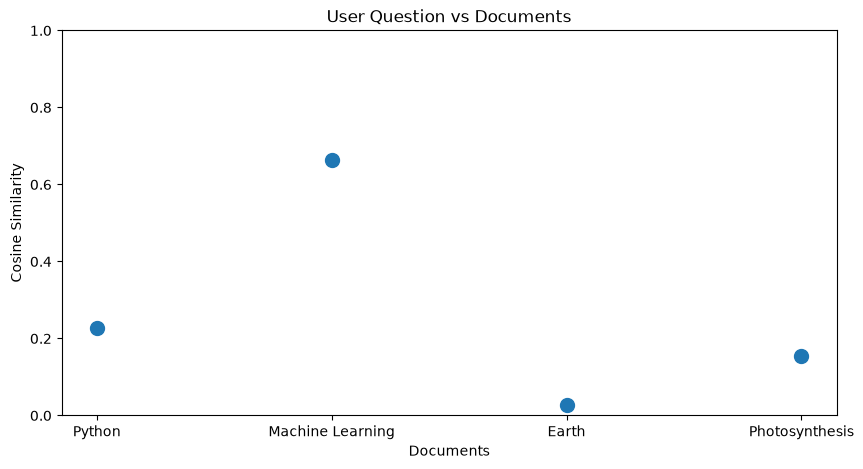

In [30]:
import matplotlib.pyplot as plt
document_names = [
    "Python",
    "Machine Learning",
    "Earth",
    "Photosynthesis"
]
scores = similarities[0]
x = range(len(document_names))

plt.figure(figsize=(10, 5))
plt.scatter(x, scores, s=100)
plt.xticks(x, document_names)
plt.xlabel("Documents")
plt.ylabel("Cosine Similarity")
plt.title("User Question vs Documents")
plt.ylim(0, 1)

plt.show()